# This is notbook used to train a recommndation for movies with similar movbies used in media logger app

## setup


In [ ]:
# install dependencies
!pip install "numpy<2" scikit-surprise --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 9.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 16.1 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2544632 sha256=6957dd1b236d408f34be0e96628ae3e98ffbb42768abbb9480187121bb0392b0
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Found existing installatio

In [1]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime



In [3]:
# import data set
movies_df = pd.read_json("movies.json")
movies_df.set_index("_id")


,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,posterUrl,backdropUrl,isActive,status,tags,ageRating,youtubeVideoId,createdAt,updatedAt,__v
_id,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30T00:00:00.000Z,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100,"[english, hindi]",https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,https://image.tmdb.org/t/p/w1280/eCynaAOgYYiw5...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",3,SPHfeNgogVs,2025-09-09T10:16:23.718Z,2025-09-16T03:24:29.642Z,0
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18T00:00:00.000Z,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155,[japanese],https://image.tmdb.org/t/p/w500/aFRDH3P7TX61FV...,https://image.tmdb.org/t/p/w1280/1RgPyOhN4DRs2...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",13,x7uLutVRBfI,2025-09-15T16:45:37.477Z,2025-09-16T03:24:18.096Z,0
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29T00:00:00.000Z,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91,[english],https://image.tmdb.org/t/p/w500/yvirUYrva23Iud...,https://image.tmdb.org/t/p/w1280/iZLqwEwUViJdS...,True,released,"[Attack, Privacy, Surveillance, Cybersecurity]",13,d9erkpdh5o0,2025-09-15T16:54:08.362Z,2025-09-16T03:23:39.022Z,0
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04T00:00:00.000Z,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129,"[english, spanish]",https://image.tmdb.org/t/p/w500/cpf7vsRZ0MYRQc...,https://image.tmdb.org/t/p/w1280/Q2OajDi2kcO6y...,True,released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0,QKHySfXqN0I,2025-09-16T03:13:21.693Z,2025-09-16T03:13:21.693Z,0
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03T00:00:00.000Z,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135,[english],https://image.tmdb.org/t/p/w500/29ES27icY5CzTc...,https://image.tmdb.org/t/p/w1280/fq8gLtrz1ByW3...,True,released,"[Supernatural, Exorcism, Haunted house, Sequel...",18,p4aWdkM5xF8,2025-09-16T03:17:33.416Z,2025-09-16T03:18:38.283Z,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68f47fde58394b4393fbff09,Nishaanchi,"Twin brothers, identical looks but different v...",8.3,"[Crime, Drama]",2025-09-19T00:00:00.000Z,"[Aaishvary Thackeray, Vedika Pinto, Monika Pan...",[Anurag Kashyap],176,[hindi],https://image.tmdb.org/t/p/w500/aDI8pTr7QDs1Qn...,https://image.tmdb.org/t/p/w1280/asjK0Ot5ocLt7...,True,released,[Critically Acclaimed],16,QKem0b7Q40I,2025-10-19T06:06:22.896Z,2025-10-19T06:06:22.896Z,0
6909f05c4e9db9b0926f6c95,Eden (2025),A group of disillusioned outsiders abandon mod...,6.3,[Survival],2025-10-23T18:30:00.000Z,"[Sydney Sweeney, Jude Law, Daniel Brühl, Vanes...",[Ron Howard],174,[english],https://image.tmdb.org/t/p/w1280/jbFEESMVbpJU8...,https://image.tmdb.org/t/p/original/rz8NcfTRcz...,True,released,[Aggressive],18,w860o1CceTk,2025-11-04T12:23:56.168Z,2025-11-04T12:25:44.839Z,0
690a182fd310dbfaf41b46a7,Old,A group of families on a tropical holiday disc...,6.3,"[Thriller, Mystery, Horror]",2021-07-21T00:00:00.000Z,"[Gael García Bernal, Vicky Krieps, Rufus Sewel...",[M. Night Shyamalan],108,[english],https://image.tmdb.org/t/p/w500/vclShucpUmPhdA...,https://image.tmdb.org/t/p/w1280/32yqxyLlWcO81...,True,released,"[Time Travel, Family Friendly]",13,A4U2pMRV9_k,2025-11-04T15:13:51.688Z,2025-11-04T15:13:51.688Z,0


# data preproceesing

some data ti be converted for better visualization and training

In [5]:
# Convert to datetime, handle missing values automatically for releasedate
movies_df['releaseDate'] = pd.to_datetime(movies_df['releaseDate'], errors='coerce')

# do the same to createdAt
movies_df["createdAt"] = pd.to_datetime(movies_df["createdAt"] , errors = "coerce")


# visulaization

In [6]:
### print the meta data about the data set

movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             330 non-null    object             
 1   title           330 non-null    object             
 2   description     330 non-null    object             
 3   averageRating   323 non-null    float64            
 4   genre           330 non-null    object             
 5   releaseDate     330 non-null    datetime64[ns, UTC]
 6   cast            330 non-null    object             
 7   directors       330 non-null    object             
 8   runTime         330 non-null    int64              
 9   languages       330 non-null    object             
 10  posterUrl       330 non-null    object             
 11  backdropUrl     330 non-null    object             
 12  isActive        330 non-null    bool               
 13  status          330 non-null    obj

In [7]:
movies_df.describe()

,averageRating,runTime,ageRating,__v
count,323.000000,330.000000,330.000000,330.0
mean,7.054799,113.951515,9.990909,0.0
std,1.017609,32.276975,7.331278,0.0
min,2.500000,6.000000,0.000000,0.0
25%,6.400000,95.000000,0.000000,0.0
50%,7.100000,110.000000,13.000000,0.0
75%,7.700000,134.750000,17.000000,0.0
max,10.000000,202.000000,18.000000,0.0


Print top 5 rows

In [8]:
movies_df.head()

,_id,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,posterUrl,backdropUrl,isActive,status,tags,ageRating,youtubeVideoId,createdAt,updatedAt,__v
0,68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100,"[english, hindi]",https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,https://image.tmdb.org/t/p/w1280/eCynaAOgYYiw5...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",3,SPHfeNgogVs,2025-09-09 10:16:23.718000+00:00,2025-09-16T03:24:29.642Z,0
1,68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155,[japanese],https://image.tmdb.org/t/p/w500/aFRDH3P7TX61FV...,https://image.tmdb.org/t/p/w1280/1RgPyOhN4DRs2...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",13,x7uLutVRBfI,2025-09-15 16:45:37.477000+00:00,2025-09-16T03:24:18.096Z,0
2,68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91,[english],https://image.tmdb.org/t/p/w500/yvirUYrva23Iud...,https://image.tmdb.org/t/p/w1280/iZLqwEwUViJdS...,True,released,"[Attack, Privacy, Surveillance, Cybersecurity]",13,d9erkpdh5o0,2025-09-15 16:54:08.362000+00:00,2025-09-16T03:23:39.022Z,0
3,68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129,"[english, spanish]",https://image.tmdb.org/t/p/w500/cpf7vsRZ0MYRQc...,https://image.tmdb.org/t/p/w1280/Q2OajDi2kcO6y...,True,released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0,QKHySfXqN0I,2025-09-16 03:13:21.693000+00:00,2025-09-16T03:13:21.693Z,0
4,68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135,[english],https://image.tmdb.org/t/p/w500/29ES27icY5CzTc...,https://image.tmdb.org/t/p/w1280/fq8gLtrz1ByW3...,True,released,"[Supernatural, Exorcism, Haunted house, Sequel...",18,p4aWdkM5xF8,2025-09-16 03:17:33.416000+00:00,2025-09-16T03:18:38.283Z,0


### **Distribution**:- lets focus on checking the distribution of data

#### Age rating

Text(0.5, 1.0, 'Age rating vs count')

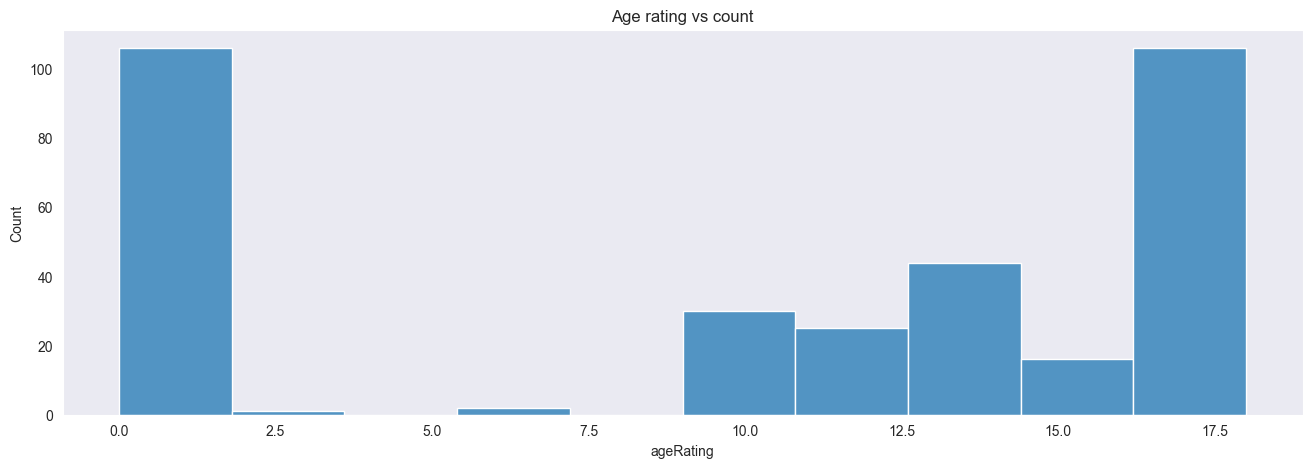

In [4]:
# lets focus on checking the  count of age rating
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

# hist graph vs count
sns.histplot( x= 'ageRating' , data = movies_df)

plt.title("Age rating vs count")



Text(0.5, 1.0, 'Age rating vs count')

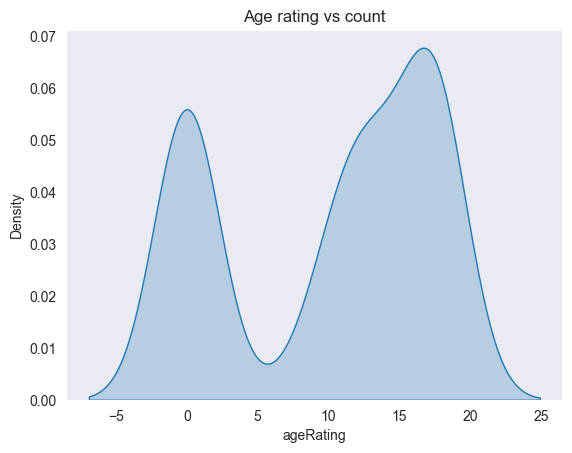

In [5]:
# kde plot
sns.kdeplot(x= "ageRating" , data = movies_df , fill = True)
plt.title("Age rating vs count")

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

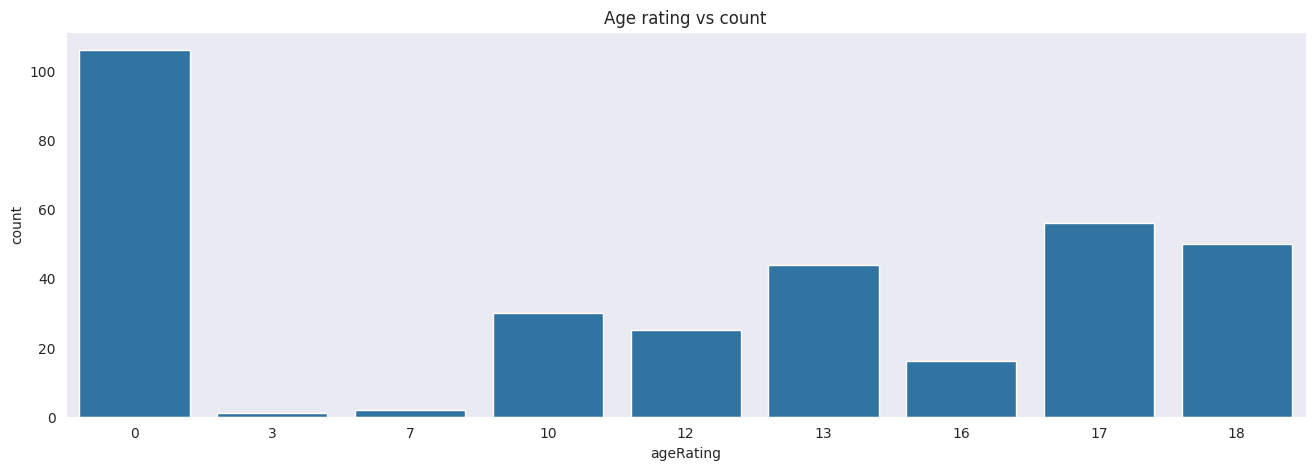

In [11]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = movies_df)

we come to come to know that a lot of the movies are above 17+  , we have some at 12+ , but below that the number is quite low and the once marked as 0 are actually unrated and will be later filtered out before training the model .

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

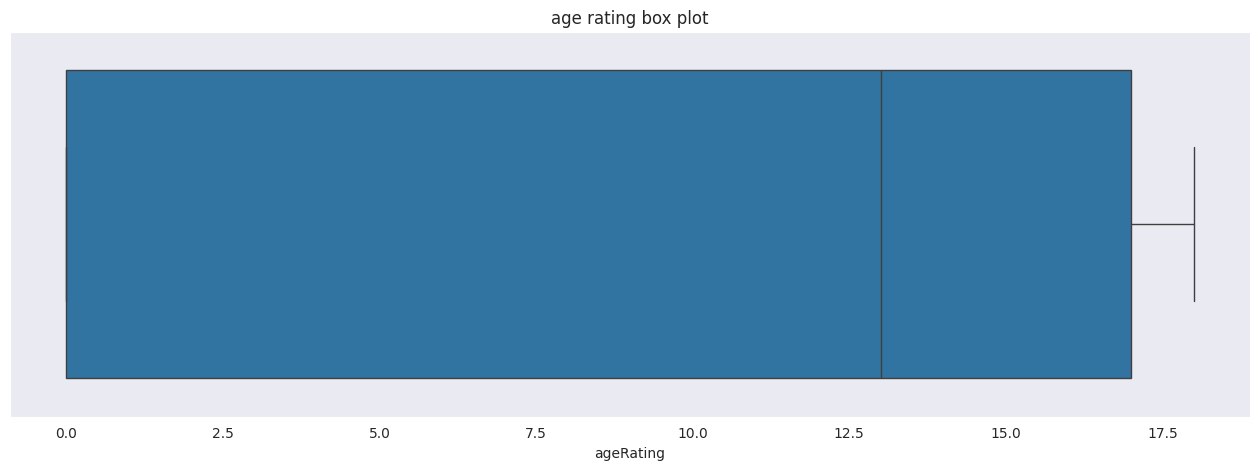

In [12]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=movies_df["ageRating"])

There are no dots outside the whiskers, which means all ageRating values are within the "expected" range .

median is towards the right as observed from the previous plots as well.

The wide box suggests a diverse set of age ratings in your movie data


#### Average rating

Text(0.5, 1.0, 'Average rating vs count')

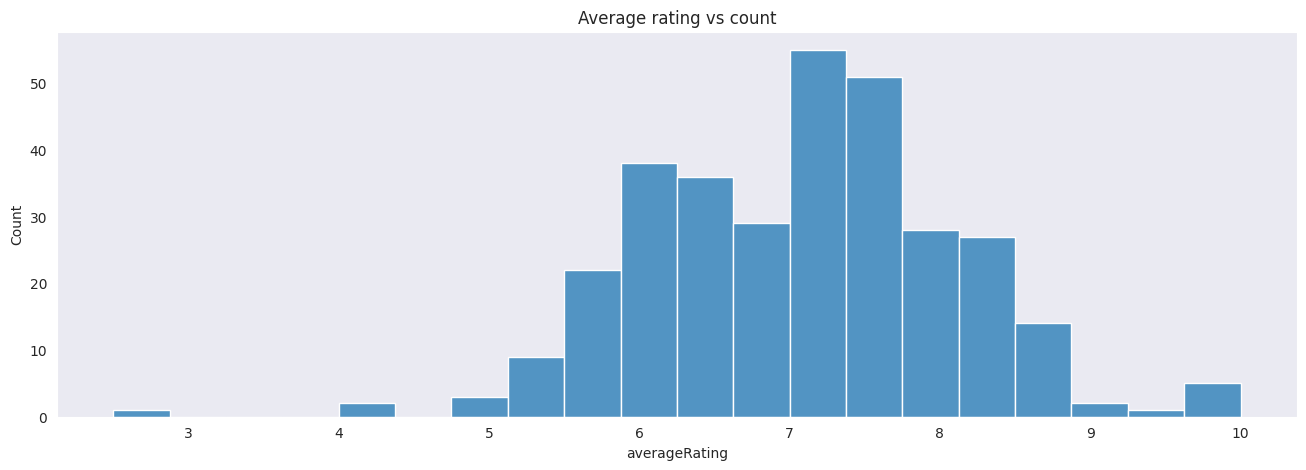

In [13]:
# lets focus on count vs the plot of average rating
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

sns.histplot( x = "averageRating" , data = movies_df)
plt.title("Average rating vs count")

<Axes: title={'center': 'distribution plots for average rating'}, xlabel='averageRating', ylabel='Density'>

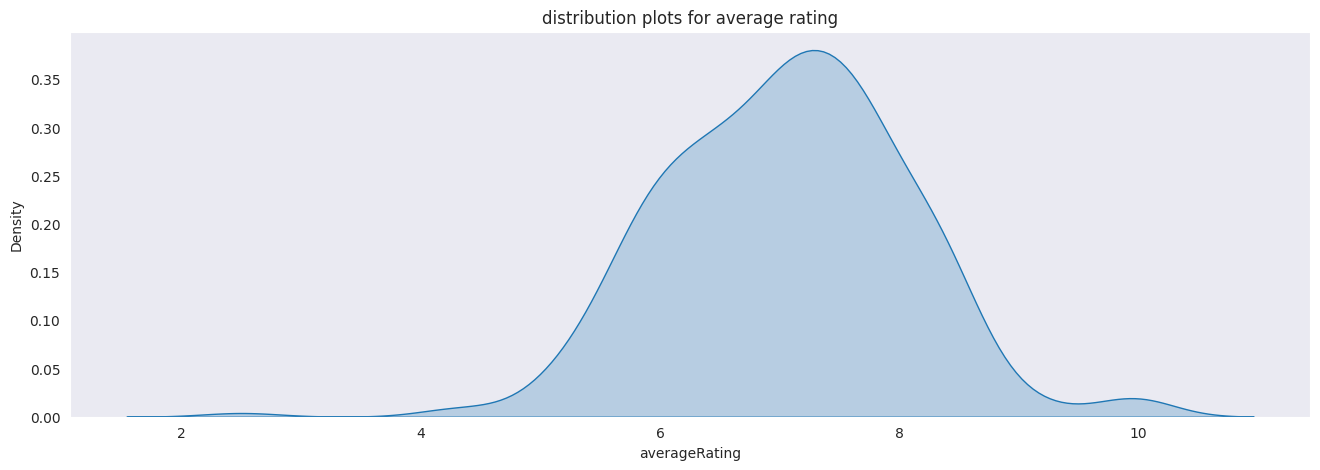

In [14]:
# lest also get the ked
plt.figure(figsize=(16 , 5));

plt.title("distribution plots for average rating")

sns.kdeplot( x = "averageRating", data = movies_df , fill = True)



from this we come to know that magority of the data have rating of 6 to 9   , as for 0 rating are same as unrated and to be removed from the model training .

Lets plot the created at with a ked plot it can be also give important relationship in case similar moves are added at the same time , or newer once are aded at same time .

#### created at

<Axes: title={'center': 'created at vs count'}, xlabel='createdAt', ylabel='Count'>

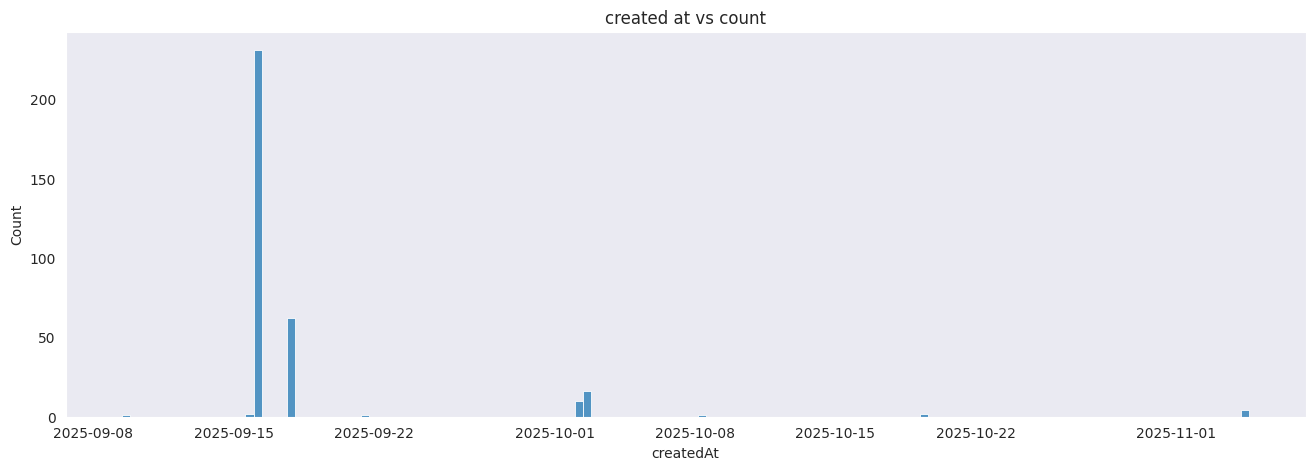

In [15]:
# hist graph of count vs created at time
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("created at vs count")
sns.histplot( x = "createdAt" , data = movies_df)

Text(0.5, 1.0, 'created at vs count')

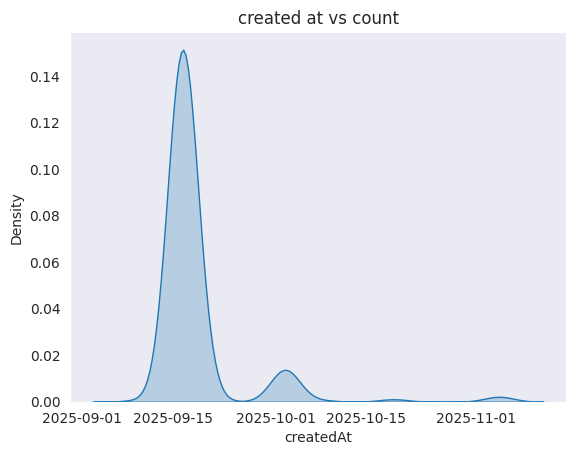

In [16]:
# create a kde chat
sns.kdeplot(x = "createdAt" , data = movies_df , fill = True)
plt.title("created at vs count")


most of the data is added at a peak time of 2025/9/15 then its reduced constant with small additions.

Lets plot a distrubution graphs for release date

#### Release date

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

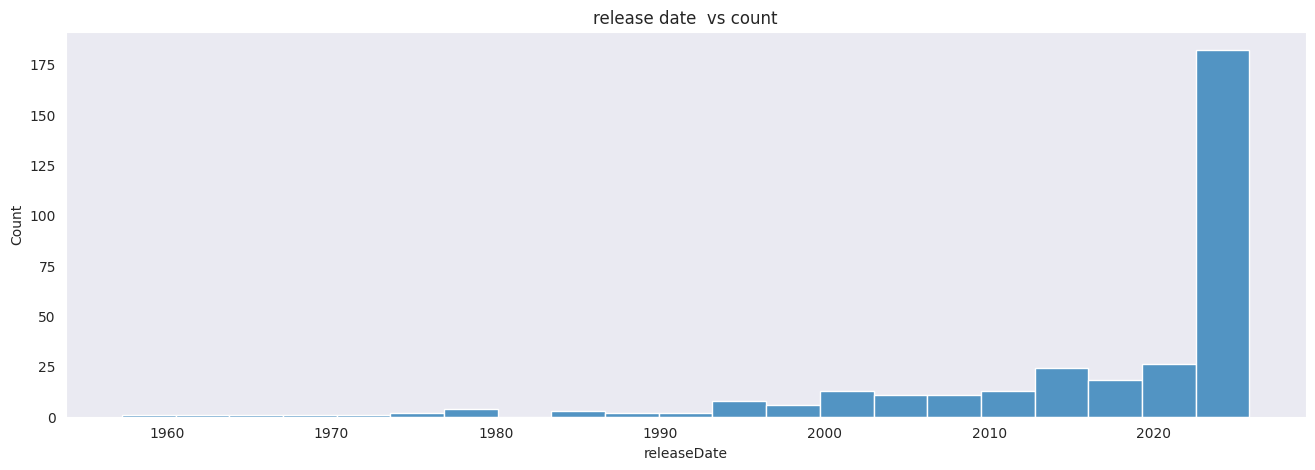

In [17]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = movies_df)


Text(0.5, 1.0, 'release date  vs count')

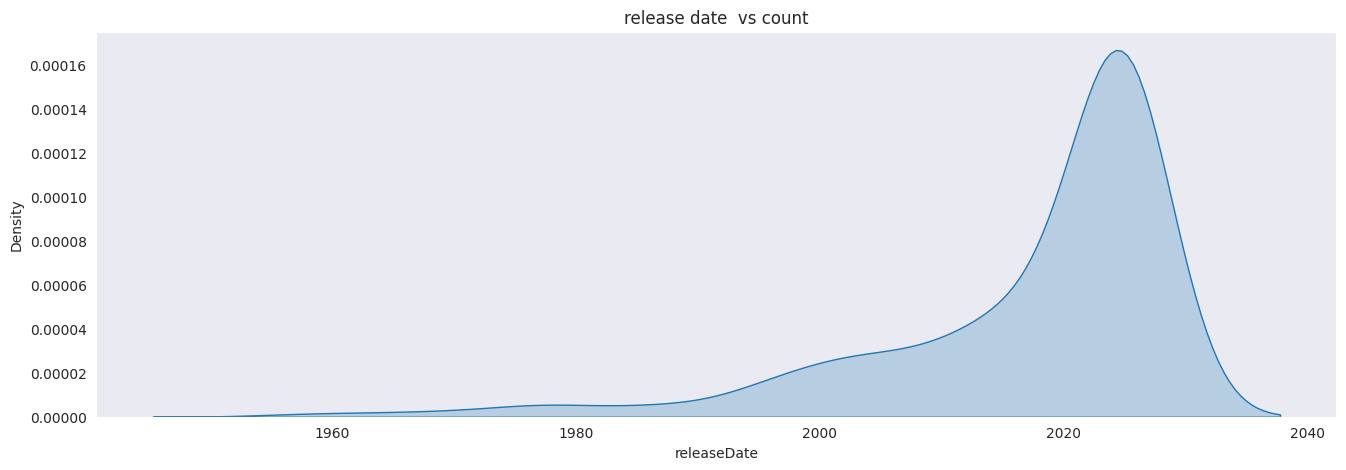

In [18]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = movies_df , fill = True)
plt.title("release date  vs count")

most of the movies are in the range of 2020 - 2025

#### Run time

<Axes: title={'center': 'Runtime vs count'}, xlabel='runTime', ylabel='Count'>

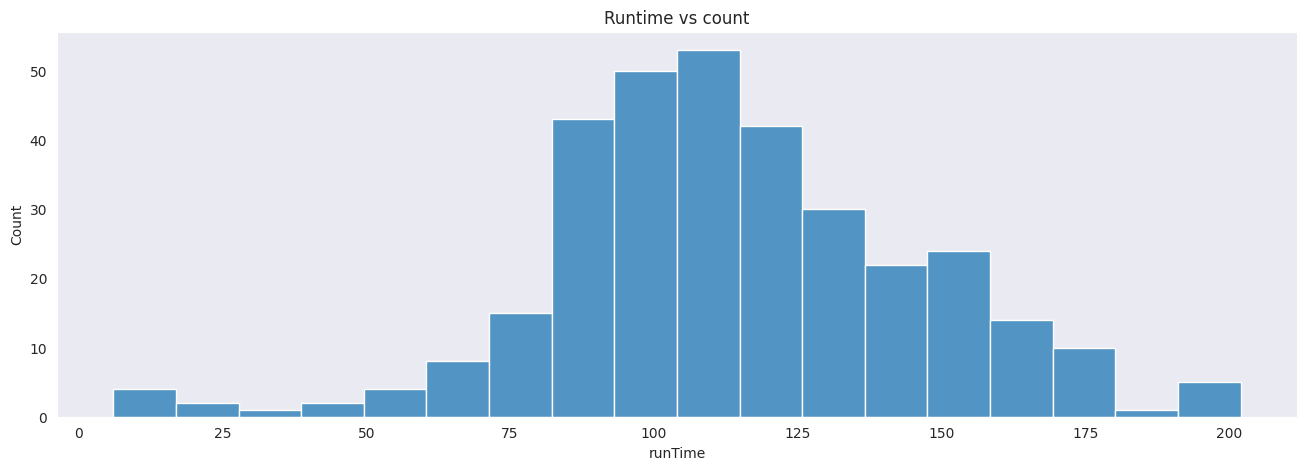

In [19]:
#now lets check the distribution of runtime

plt.figure(figsize= (16, 5));
plt.title("Runtime vs count")

# lets have a histplot first
sns.histplot(x = "runTime", data = movies_df)

<Axes: title={'center': 'Runtime vs count'}, xlabel='runTime', ylabel='Density'>

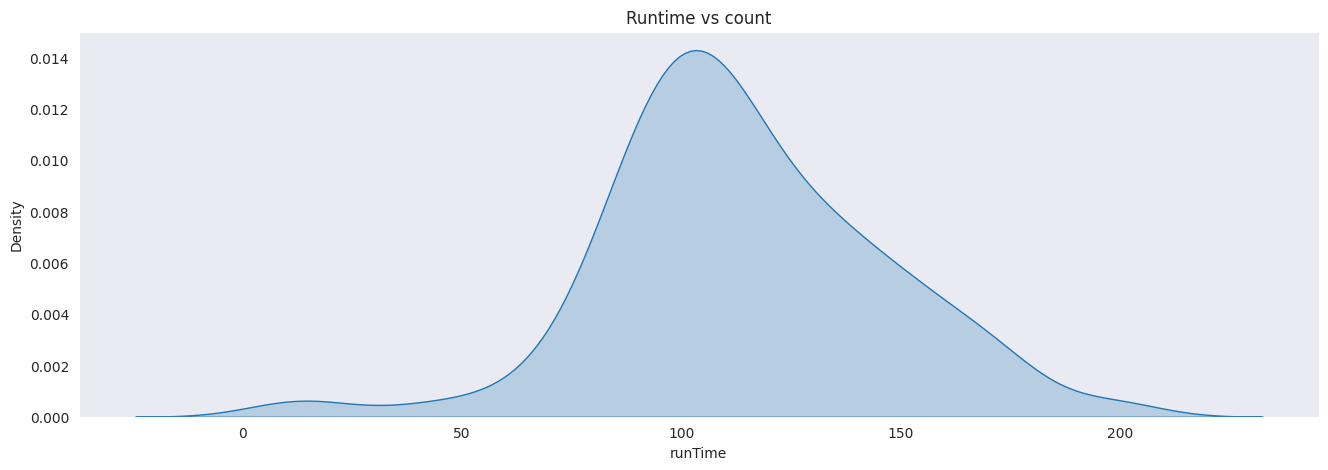

In [20]:
plt.figure(figsize= (16, 5));
plt.title("Runtime vs count")

# lets have a kde plot
sns.kdeplot(x = "runTime", data = movies_df , fill = True)

This is as expected mazority are at the range of 75 to 150

### Categorical Feature Analysis

In [21]:
#lets compare movie count by genere
movies_analysis =  movies_df.copy() # create a copy

# Replace missing or empty genre lists with a placeholder
movies_analysis['genre_filled'] = movies_analysis['genre'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ['Unknown'])

# Explode and count including the placeholder
exploded_genres = movies_analysis['genre_filled'].explode()
genre_counts = exploded_genres.value_counts()
# lets check the count
genre_counts



,count
genre_filled,
Action,121
Drama,106
Adventure,94
Thriller,82
Comedy,72
Science Fiction,63
Romance,57
Fantasy,50
Animation,47


In [22]:
# lets convertthis to a df
genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

genre_df

,Genre,Count
0,Action,121
1,Drama,106
2,Adventure,94
3,Thriller,82
4,Comedy,72
5,Science Fiction,63
6,Romance,57
7,Fantasy,50
8,Animation,47
9,Horror,46


<Axes: title={'center': 'Genre Counts in Movies data set'}, xlabel='Count', ylabel='Genre'>

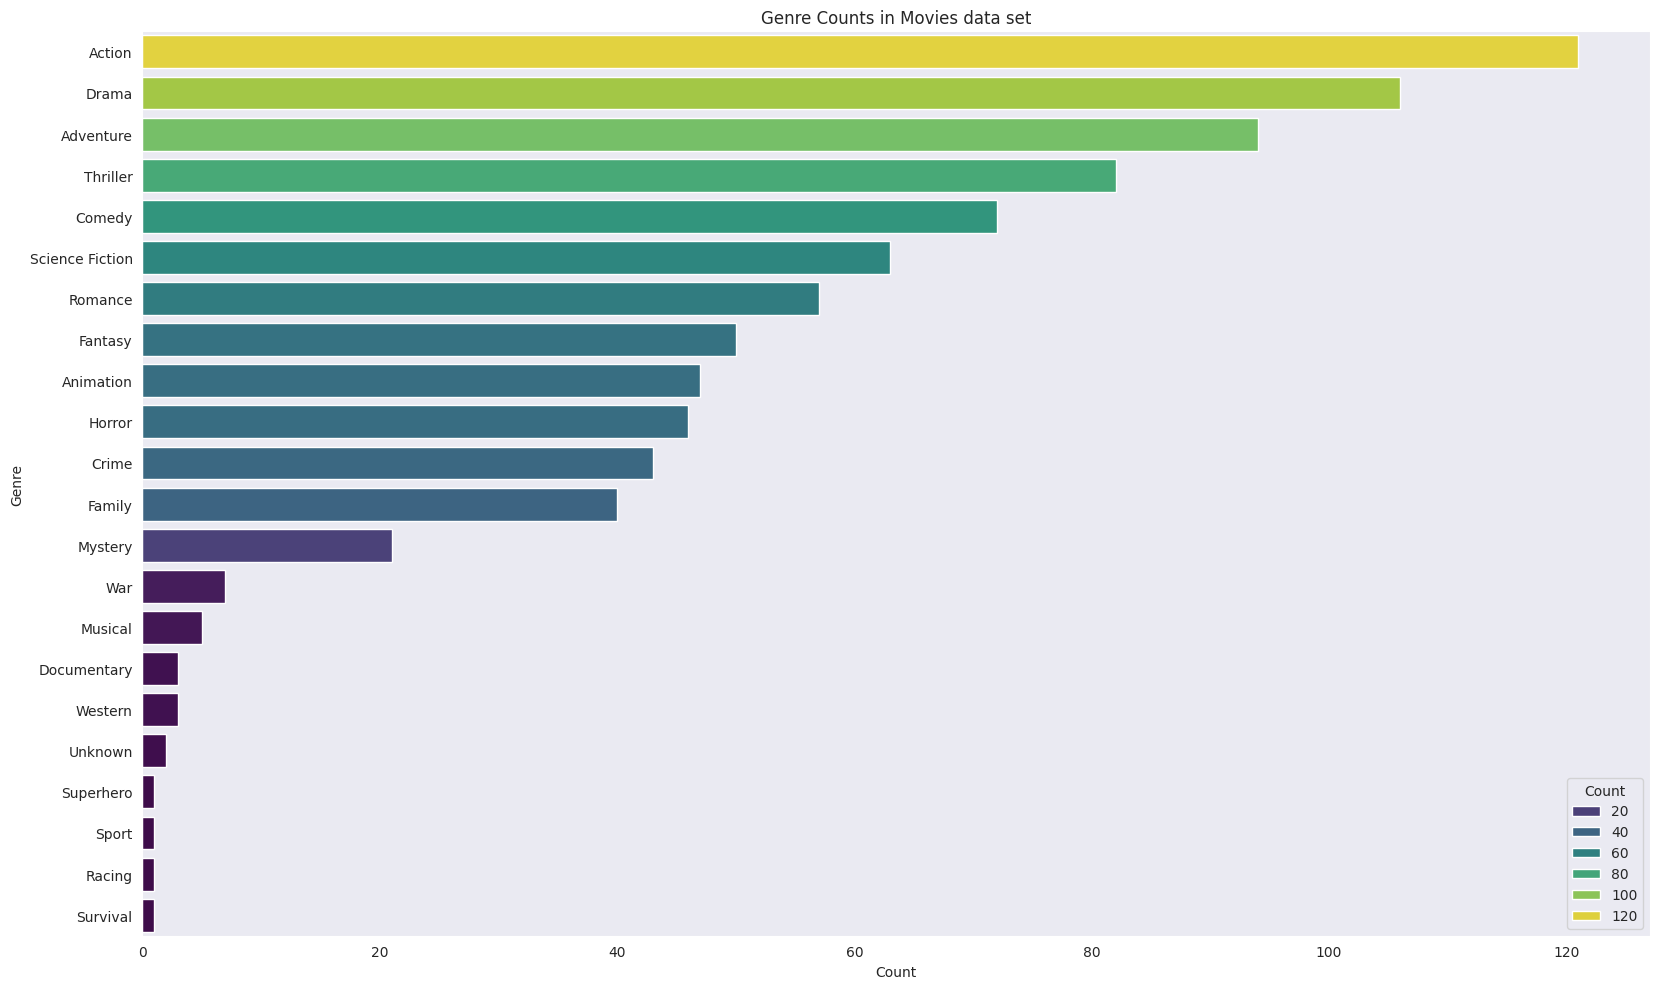

In [23]:
# lets plot the geners to see the distribution
sns.set_style("dark")
plt.figure(figsize=(16, 10));
plt.title('Genre Counts in Movies data set')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='Count', y='Genre', data=genre_df, palette='viridis' , hue="Count")


observation here we can see the distribution of genere currently action is quite hight .

<Axes: title={'center': 'Tag Counts in Movies data set top 15'}, xlabel='Count', ylabel='Tags'>

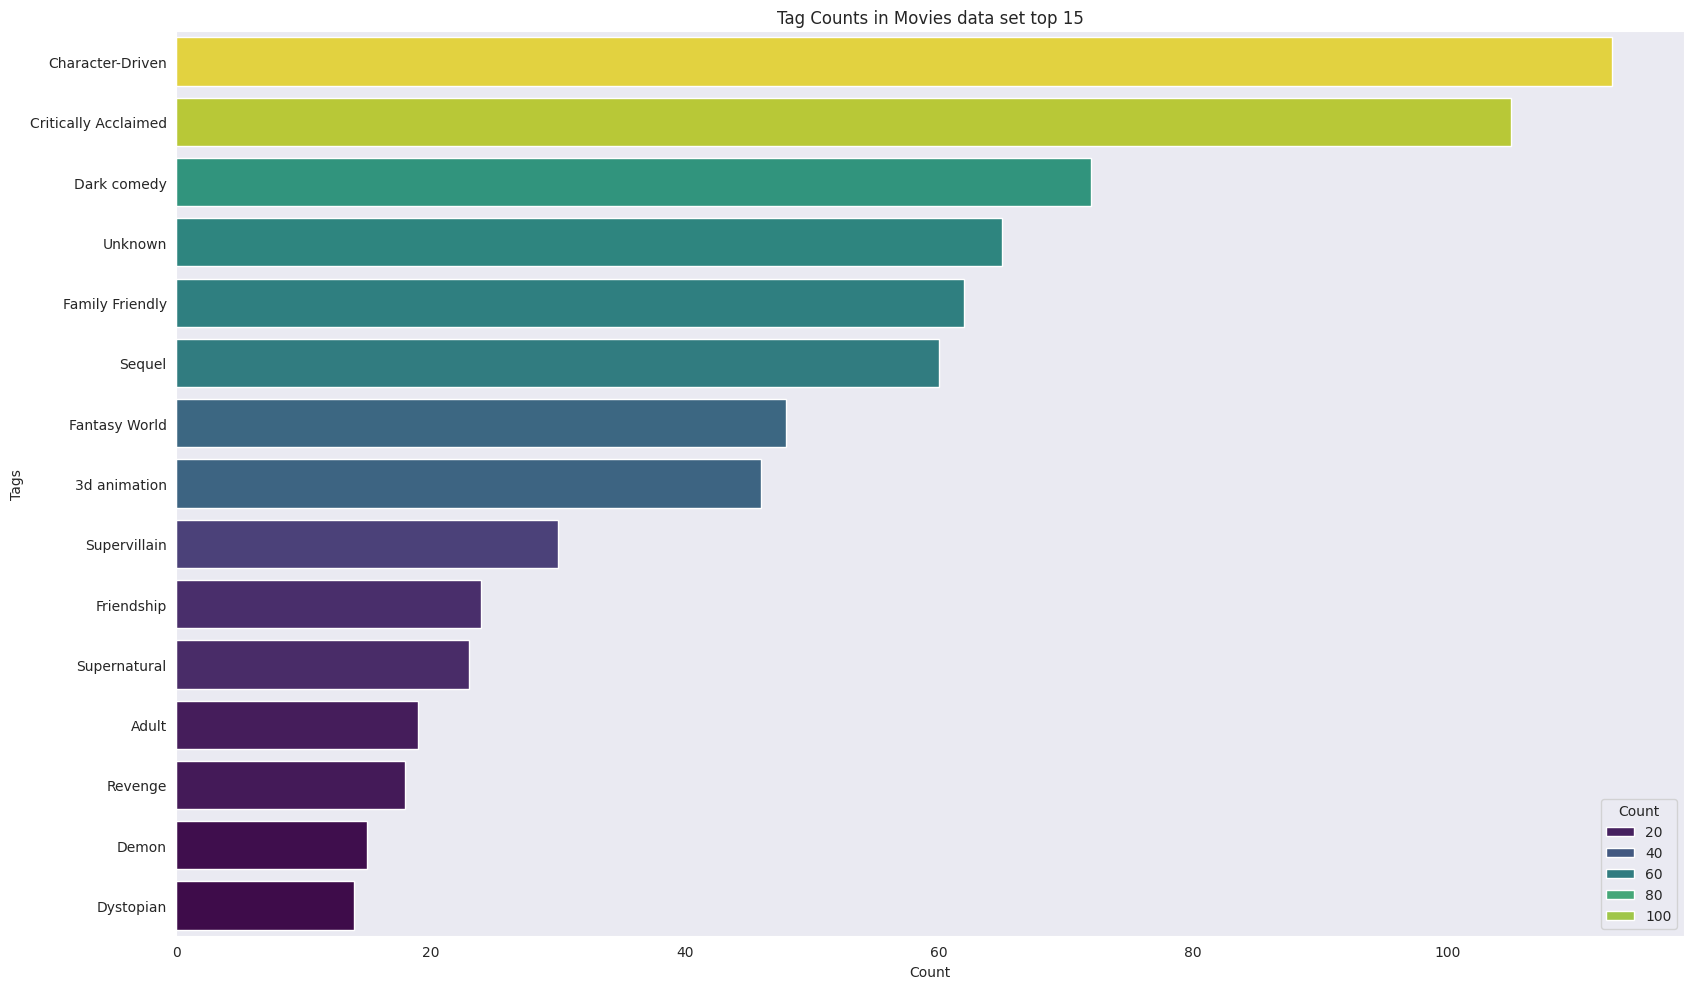

In [24]:
# lets do the same for tags
# replace epty with Unknown
movies_analysis["tags_filled"] = movies_analysis["tags"].apply(lambda x : x if isinstance(x , list) and len(x) > 0 else ["Unknown"])

# explore the tags
exploded_tags = movies_analysis["tags_filled"].explode()
tags_count = exploded_tags.value_counts()

# convert to df
tags_df = tags_count.reset_index()
tags_df.columns = ['Tag', 'Count']

# lets plot the tags to see the distribution
sns.set_style("dark")
plt.figure(figsize=(16, 10));
plt.title('Tag Counts in Movies data set top 15')
plt.xlabel('Count')
plt.ylabel('Tags')
plt.tight_layout()
sns.barplot(x='Count', y='Tag', data=tags_df.head(15), palette='viridis' , hue="Count")

we get a clear picture from this abouve plot the distribution of tags

<Axes: xlabel='isActive', ylabel='count'>

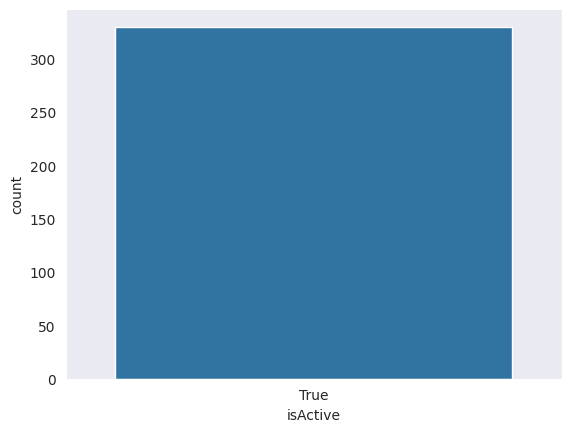

In [25]:
# lets also have a check on the distribution of active and non active
sns.countplot(x= "isActive" , data = movies_df )

from current observation all the movies are active , we probebly dont really want to tarin on inactive movies as well . so any inactive movies will be excluded from training later .

In [37]:
# now lets analize some relation like what per sent of average ratings is given by tags
exploded_genre_rating =  movies_analysis.explode("genre")

# lets drop any missing values
exploded_genre_rating = exploded_genre_rating.dropna(subset= ["genre" , "averageRating"])

# group by genere : calculate the count and mean of average rating
genre_stats = exploded_genre_rating.groupby("genre").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

genre_stats



,genre,Count,AvgRating
0,Action,119,7.103361
1,Adventure,94,7.390426
2,Animation,46,7.726087
3,Comedy,72,7.045833
4,Crime,42,7.216667
5,Documentary,3,6.600000
6,Drama,103,7.093204
7,Family,40,7.560000
8,Fantasy,50,7.410000
9,Horror,45,6.511111


In [39]:
# lets sort by count
genre_stats = genre_stats.sort_values("Count" , ascending=False)
genre_stats.head()

,genre,Count,AvgRating
0,Action,119,7.103361
6,Drama,103,7.093204
1,Adventure,94,7.390426
18,Thriller,79,7.002532
3,Comedy,72,7.045833


<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

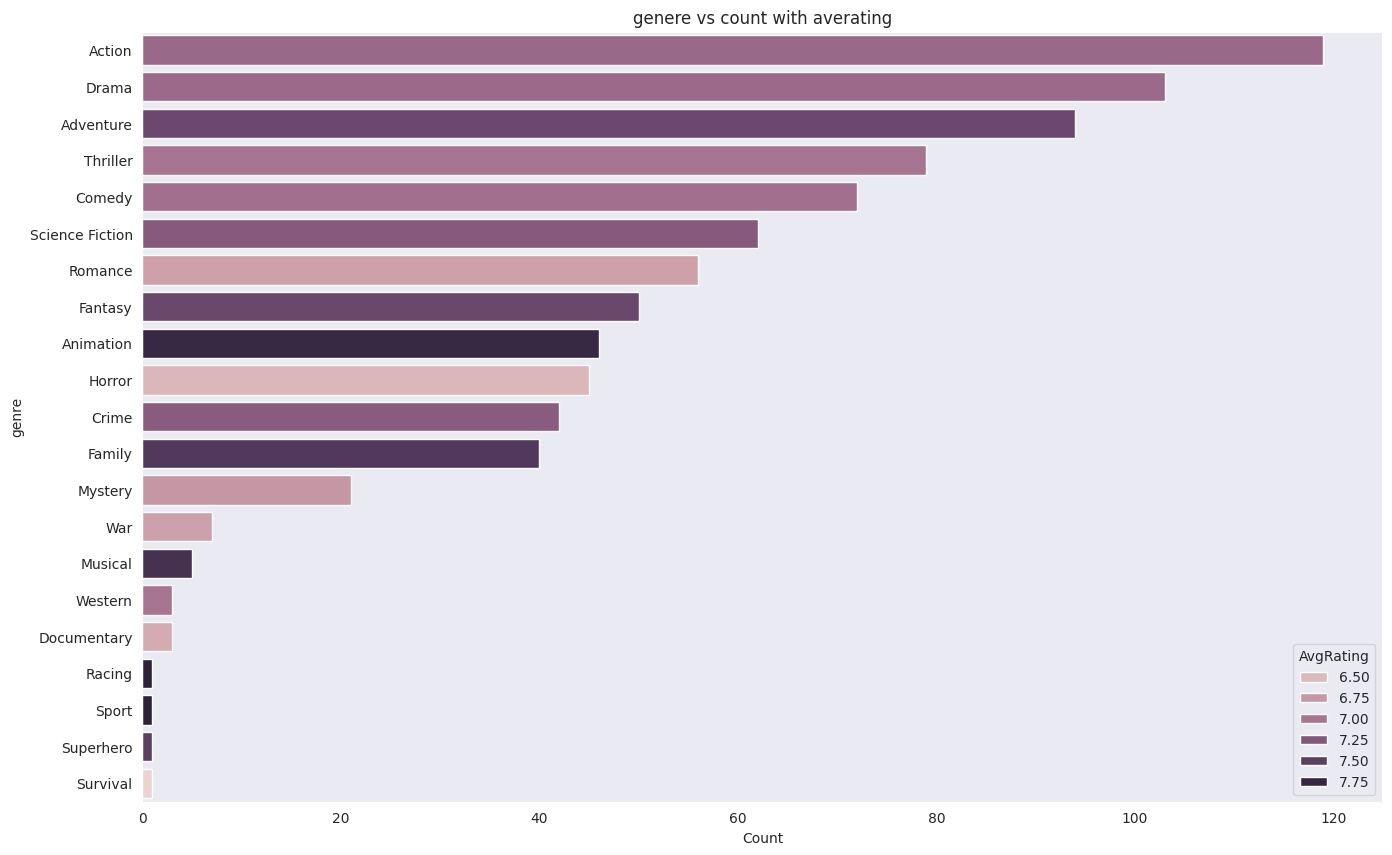

In [44]:
# lets plot the graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

from this we can crealy observe the darkest color genere which is highly rating .

/tmp/ipython-input-1961179228.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


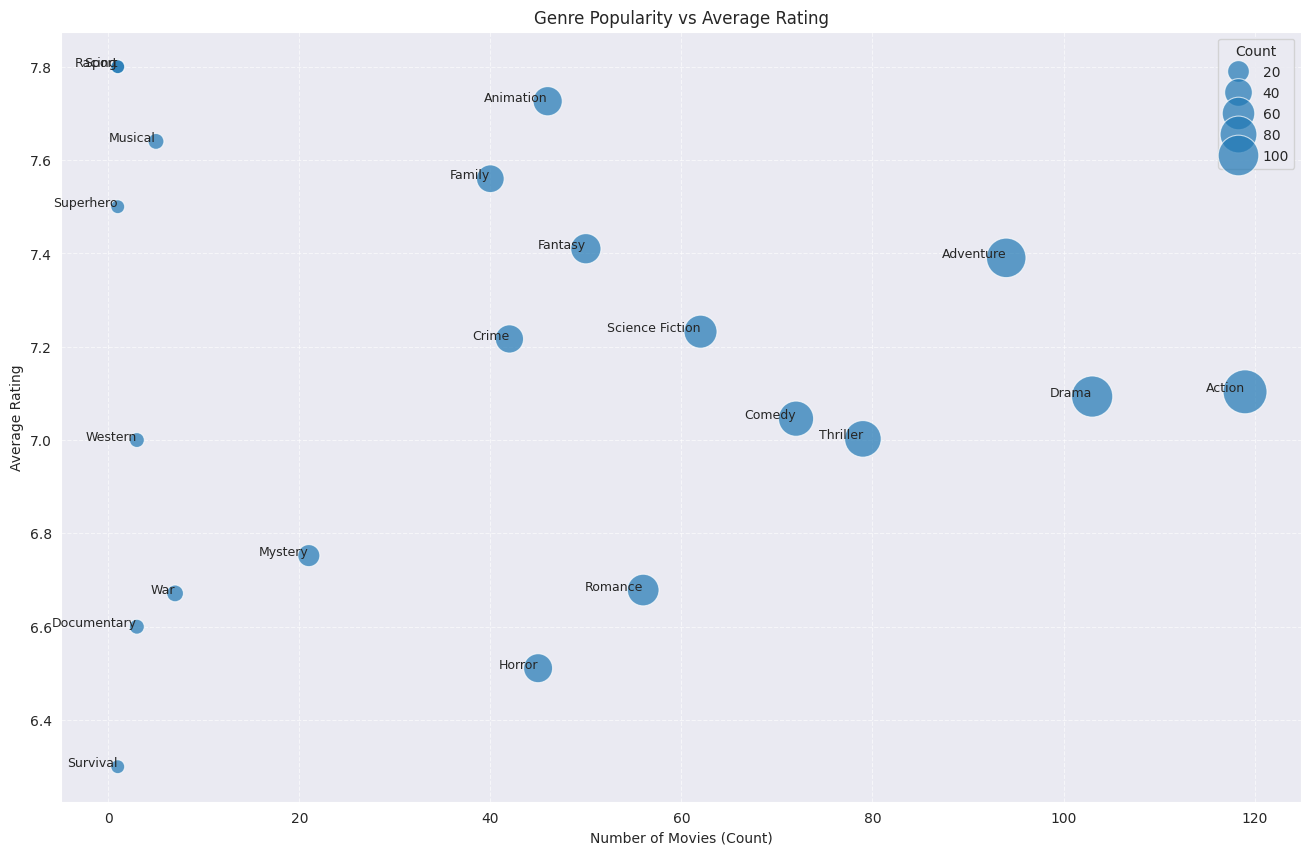

In [48]:
# let get a scatter plot for better visulization
plt.figure(figsize=(16, 10));
sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with genre names for better readability
for i, row in genre_stats.iterrows():
    plt.text(row['Count'], row['AvgRating'], row['genre'], fontsize=9, ha='right')

plt.title('Genre Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

In [50]:
# lets also visulaize tags for bettr undersatnding
exploded_tags_rating =  movies_analysis.explode("tags")

# lets drop any missing values
exploded_tags_rating = exploded_tags_rating.dropna(subset= ["tags" , "averageRating"])

# group by tags : calculate the count and mean of average rating
tag_stats = exploded_tags_rating.groupby("tags").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

tag_stats

,tags,Count,AvgRating
0,3d animation,44,7.727273
1,Adult,19,7.300000
2,Aggressive,10,7.490000
3,Antagonistic,4,7.725000
4,Artificial intelligence,10,7.430000
...,...,...,...
74,Trance,2,7.050000
75,Violent,3,6.333333
76,Warrior,4,7.300000
77,Wedding,4,6.750000


In [51]:
# lets sort by count
tag_stats.sort_values("Count" , ascending=False)

,tags,Count,AvgRating
11,Character-Driven,112,7.459821
16,Critically Acclaimed,105,8.147619
21,Dark comedy,72,7.052778
27,Family Friendly,61,7.596721
59,Sequel,59,7.188136
...,...,...,...
28,Fandom,1,8.300000
61,Slow Burn,1,8.300000
58,Save the world,1,8.300000
50,Privacy,1,4.300000


from matplotlib import pyplot as plt
_df_0['Count'].plot(kind='hist', bins=20, title='Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['AvgRating'].plot(kind='hist', bins=20, title='AvgRating')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='Count', y='AvgRating', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Count'].plot(kind='line', figsize=(8, 4), title='Count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['AvgRating'].plot(kind='line', figsize=(8, 4), title='AvgRating')
plt.gca().spines[['top', 'right']].set_visible(False)

<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

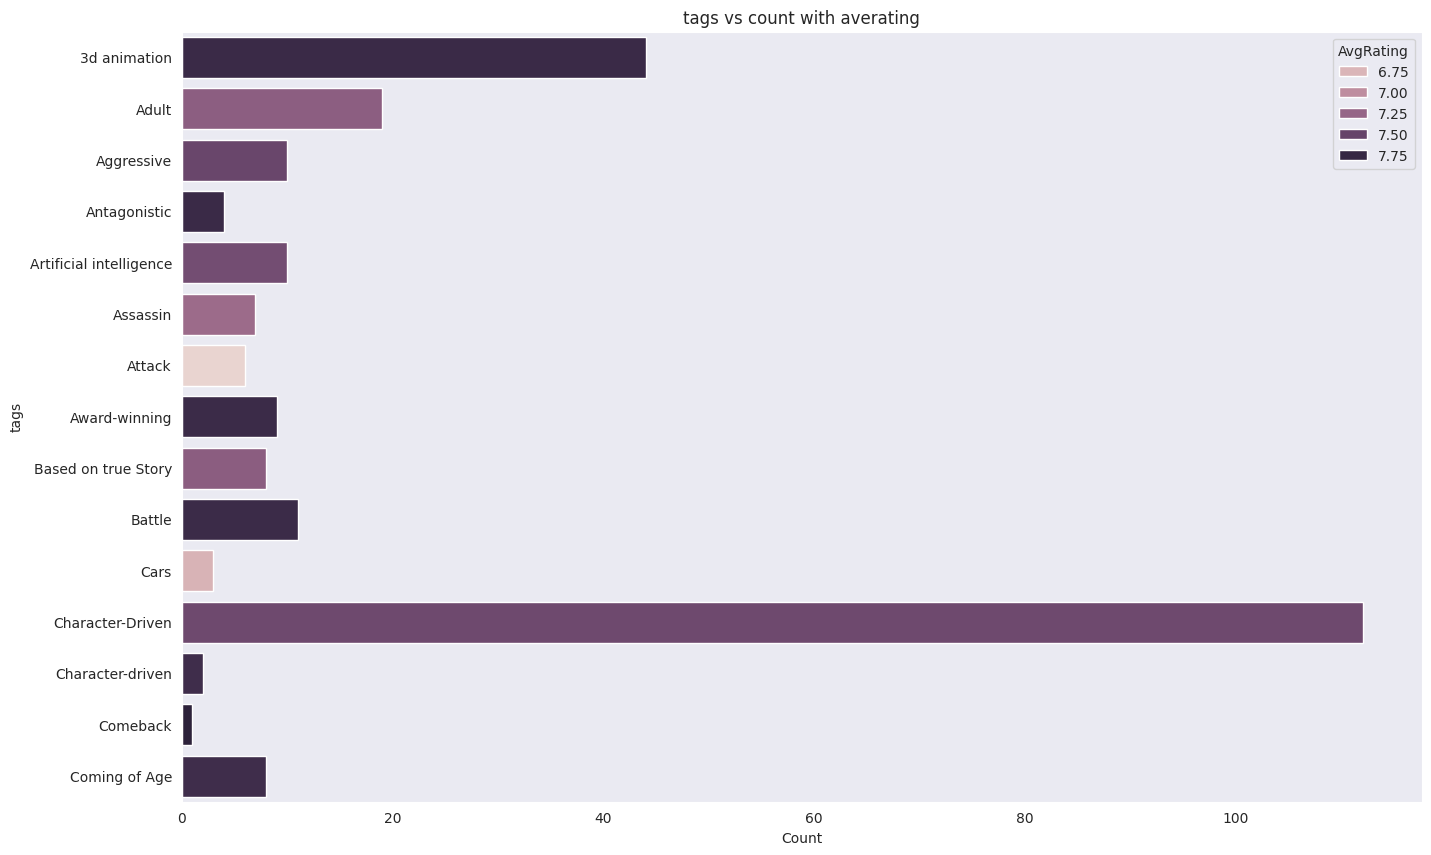

In [52]:
# lets plot the graph lets only take top 15
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = genre_stats.head(15) , hue= "AvgRating")

/tmp/ipython-input-3714933499.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = tag_stats.head(15) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


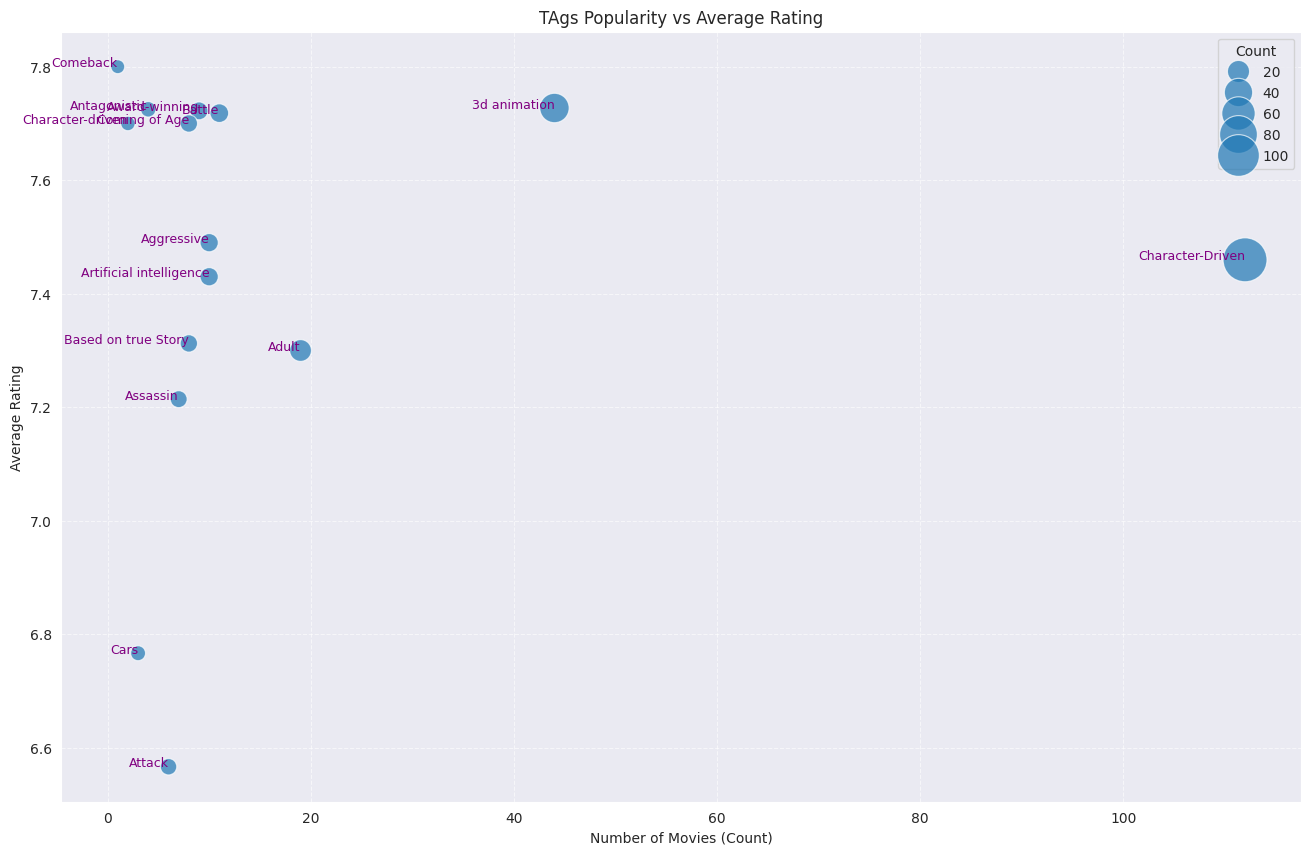

In [58]:
# let get a scatter plot for better visulization lets only take top 15
plt.figure(figsize=(16, 10));
sns.scatterplot(data = tag_stats.head(15) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with genre names for better readability
for i, row in tag_stats.head(15).iterrows():
    plt.text(row['Count'], row['AvgRating'], row['tags'], fontsize=9, ha='right' , color="purple")

plt.title('Tags Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

              tags  Count  AvgRating
18    Cult Classic      1   8.500000
28          Fandom      1   8.300000
40           K-pop      1   8.300000
61       Slow Burn      1   8.300000
58  Save the world      1   8.300000
..             ...    ...        ...
75         Violent      3   6.333333
72           Thief      1   5.800000
68    Surveillance      2   5.050000
19   Cybersecurity      1   4.300000
50         Privacy      1   4.300000

[79 rows x 3 columns]


<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

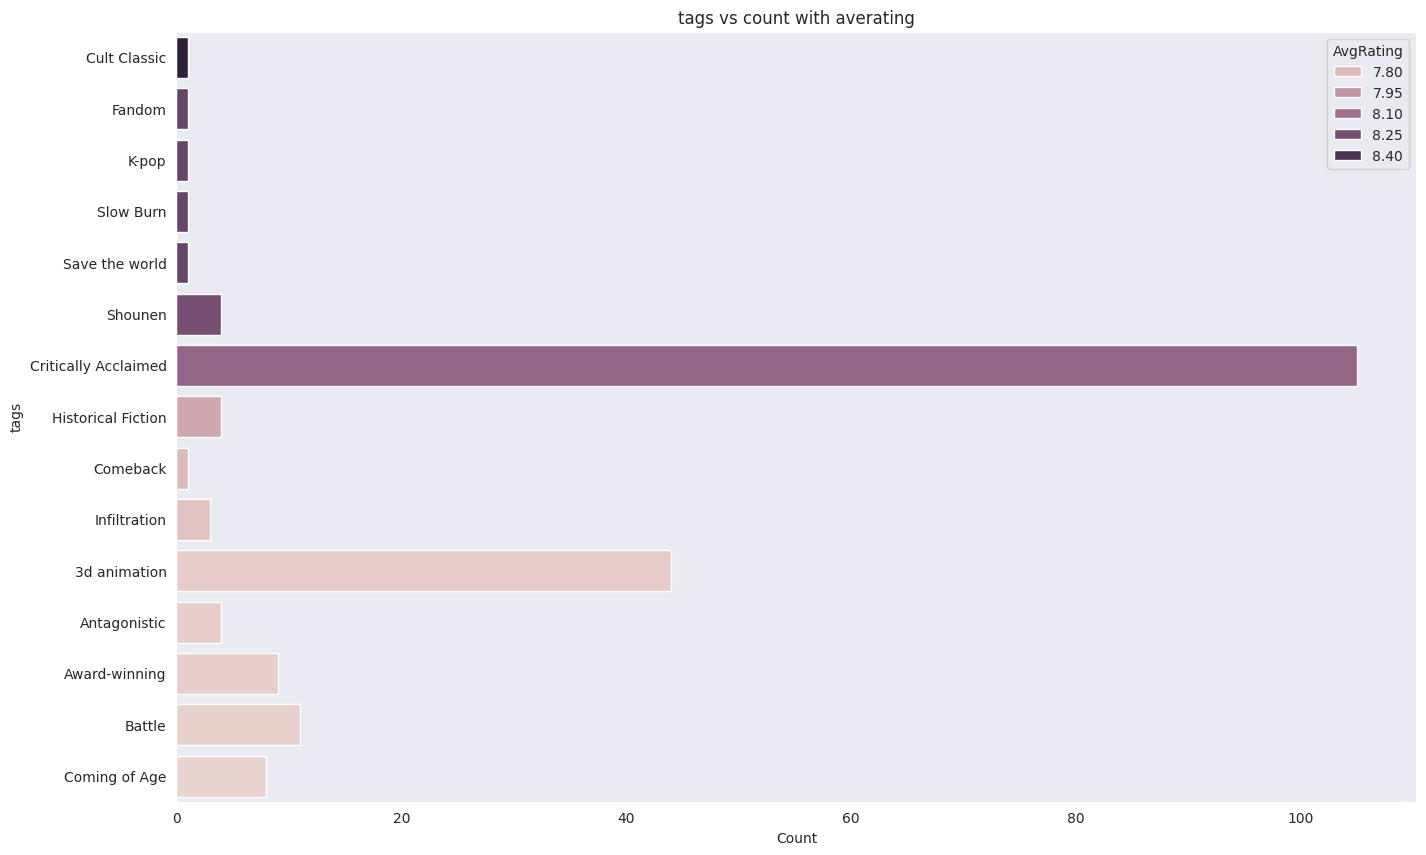

In [66]:
# lets also have plots with sorted by average rating
tag_stats = tag_stats.sort_values("AvgRating" , ascending=False)
print(tag_stats)
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tag_stats.head(15) , hue= "AvgRating")

                    tags  Count  AvgRating
11      Character-Driven    112   7.459821
16  Critically Acclaimed    105   8.147619
21           Dark comedy     72   7.052778
27       Family Friendly     61   7.596721
59                Sequel     59   7.188136
..                   ...    ...        ...
18          Cult Classic      1   8.500000
40                 K-pop      1   8.300000
72                 Thief      1   5.800000
19         Cybersecurity      1   4.300000
50               Privacy      1   4.300000

[79 rows x 3 columns]


<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

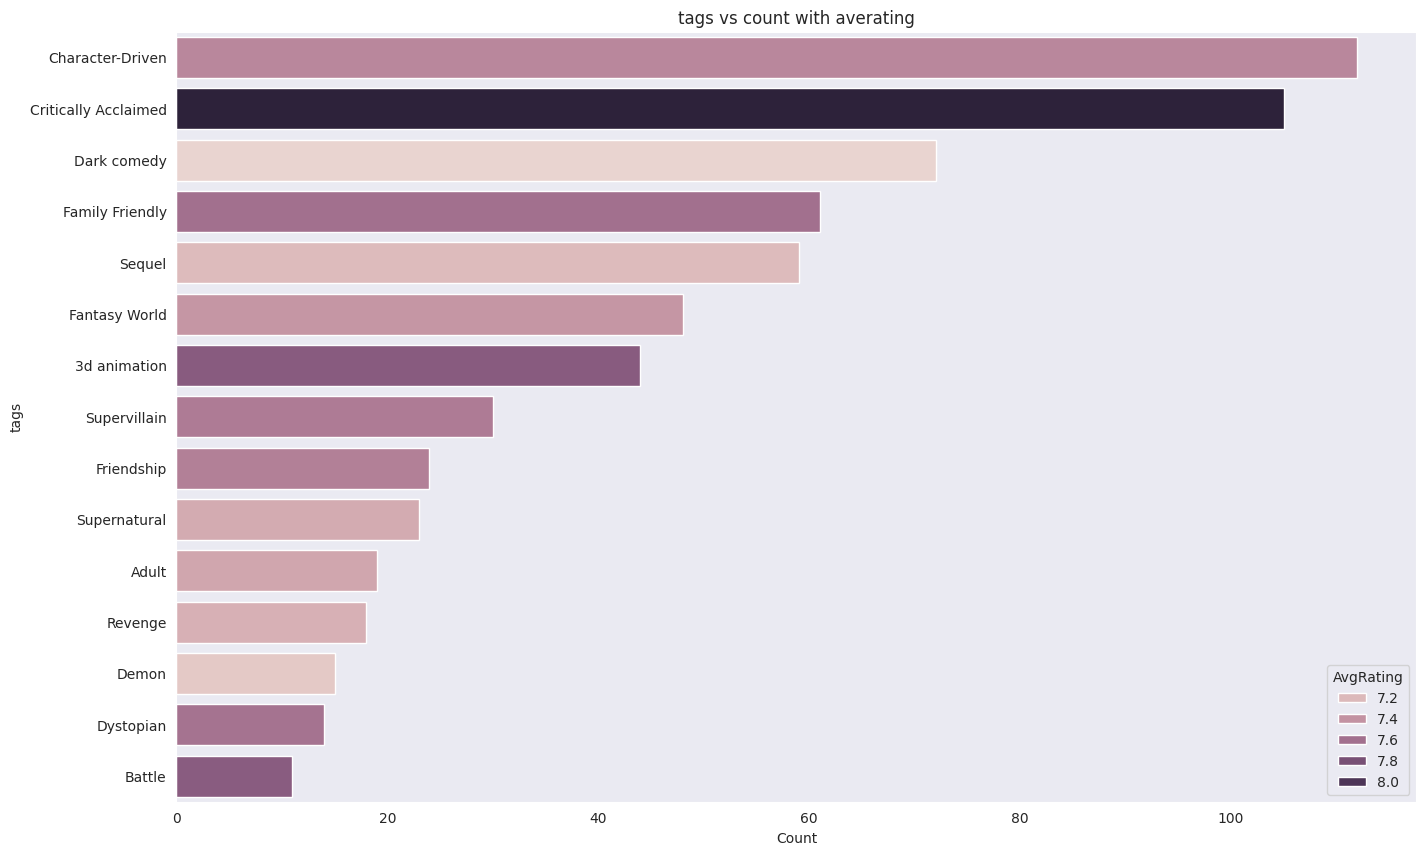

In [67]:
# lets also have plots with sorted by count
tag_stats = tag_stats.sort_values("Count" , ascending=False)
print(tag_stats)
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tag_stats.head(15) , hue= "AvgRating")